# Hubbyness vs CIC3 Metrics: BA Rewiring Sweep

Sweeps edge-rewiring fraction from 0 (pure BA, power-law degree) to 1
(maximally randomized degree) using `RewiredBAGenerator`. For each
rewiring level, runs CIC3 simulations at three values of
$\lambda$ (rescaled edge infectivity) and measures:

- **Attainment** $A_g$ and time-discounted attainment $A_g^{td}$
- **Deadweight** $D_g$
- **Penetration** $P_g$

For each metric we produce two plots:
1. Lines for each $\lambda$ value separately
2. Averaged across $\lambda$ values

For attainment plots, $A_g^{td}$ is the solid line and $A_g$ is a faint
line behind it with shading between them (matching the convention from
`cic3_attainment_sweep.ipynb`).

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import pickle
import hashlib
import os

from scm import RewiredBAGenerator, MultiRandomSeeding
from scm.cic3_simulator import CIC3Simulator
from scm.analysis import (
    attainment,
    time_discounted_attainment,
    exponential_decay,
    deadweight,
    penetration,
)

# --- Cache helpers ---
CACHE_DIR = '../results/hubbyness_rewiring_sweep'

def _param_fingerprint(**kwargs):
    raw = str(sorted(kwargs.items()))
    return hashlib.md5(raw.encode()).hexdigest()[:12]

def _cache_path(name):
    return os.path.join(CACHE_DIR, f'{name}.pkl')

def save_cache(name, obj, **fingerprint_kwargs):
    os.makedirs(CACHE_DIR, exist_ok=True)
    fp = _param_fingerprint(**fingerprint_kwargs)
    path = _cache_path(name)
    with open(path, 'wb') as f:
        pickle.dump({'fingerprint': fp, 'data': obj}, f)
    print(f'  Cached {name} -> {path} (fp={fp})')

def load_cache(name, **fingerprint_kwargs):
    path = _cache_path(name)
    if not os.path.exists(path):
        return None
    fp = _param_fingerprint(**fingerprint_kwargs)
    with open(path, 'rb') as f:
        blob = pickle.load(f)
    if blob['fingerprint'] != fp:
        print(f'  Cache stale for {name} (disk={blob["fingerprint"]}, current={fp})')
        return None
    print(f'  Loaded {name} from cache (fp={fp})')
    return blob['data']

## Parameters

In [2]:
# --- Network ---
N = 2000
BA_M = 5
BA_M_DELTA = 2

# --- CIC3 ---
C = 10
QUOTAS = np.full(C, N // C)  # equal quotas, sum == N (no slack)
NUM_SEEDS_PER_CONTAGION = [1] * C

# --- Simulation ---
T_MAX = 1000
NUM_TRIALS = 15

# --- Rewiring sweep ---
REWIRE_FRACS = np.linspace(0, 1, 21)  # 0.0, 0.05, ..., 1.0

# --- Lambda values (rescaled edge infectivity) ---
LAMBDA_VALS = [0.7, 1.0, 1.3]
LAMBDA_DELTA = 2.0  # fixed for all runs

# --- Time discount ---
DECAY_RATE = 0.01
V = exponential_decay(DECAY_RATE)

# --- Topology seed (base BA graph) ---
TOPO_SEED = 2025

print(f'N = {N}, C = {C}, quotas sum = {QUOTAS.sum()}')
print(f'Seeds per contagion = {NUM_SEEDS_PER_CONTAGION}')
print(f'Trials per point = {NUM_TRIALS}')
print(f'Rewire sweep: {REWIRE_FRACS[0]:.2f} .. {REWIRE_FRACS[-1]:.2f} ({len(REWIRE_FRACS)} pts)')
print(f'Lambda values: {LAMBDA_VALS}')
print(f'Lambda_delta = {LAMBDA_DELTA}')

N = 2000, C = 10, quotas sum = 2000
Seeds per contagion = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Trials per point = 15
Rewire sweep: 0.00 .. 1.00 (21 pts)
Lambda values: [0.7, 1.0, 1.3]
Lambda_delta = 2.0


## Generate topologies

One BA-based graph per rewiring fraction. All share the same topology seed
so the base BA graph is identical; only the rewiring differs.

In [3]:
topologies = {}
for rf in REWIRE_FRACS:
    gen = RewiredBAGenerator(m=BA_M, m_delta=BA_M_DELTA, rewire_frac=rf, N=N)
    links, triangles = gen.generate(seed=TOPO_SEED)
    topologies[rf] = {
        'links': links,
        'triangles': triangles,
        'N': gen.N,
        'k_avg': gen.k_avg,
        'k_d_avg': gen.k_delta_avg,
    }
    print(f'  rewire_frac={rf:.2f}: k_avg={gen.k_avg:.2f}, k_delta_avg={gen.k_delta_avg:.2f}')

BA nodes added: 2000/2000
Realized k_avg = 21.13, k_delta_avg = 5.94
RewiredBA: rewire_frac=0.00, rewired 0/21134 edges, realized k_avg = 21.13, k_delta_avg = 5.94
  rewire_frac=0.00: k_avg=21.13, k_delta_avg=5.94
BA nodes added: 2000/2000
Realized k_avg = 21.13, k_delta_avg = 5.94
RewiredBA: rewire_frac=0.05, rewired 1057/21134 edges, realized k_avg = 21.13, k_delta_avg = 5.94
  rewire_frac=0.05: k_avg=21.13, k_delta_avg=5.94
BA nodes added: 2000/2000
Realized k_avg = 21.13, k_delta_avg = 5.94
RewiredBA: rewire_frac=0.10, rewired 2113/21134 edges, realized k_avg = 21.13, k_delta_avg = 5.94
  rewire_frac=0.10: k_avg=21.13, k_delta_avg=5.94
BA nodes added: 2000/2000
Realized k_avg = 21.13, k_delta_avg = 5.94
RewiredBA: rewire_frac=0.15, rewired 3170/21134 edges, realized k_avg = 21.13, k_delta_avg = 5.94
  rewire_frac=0.15: k_avg=21.13, k_delta_avg=5.94
BA nodes added: 2000/2000
Realized k_avg = 21.13, k_delta_avg = 5.94
RewiredBA: rewire_frac=0.20, rewired 4227/21134 edges, realized k_

## Simulation

For each (rewire_frac, $\lambda$) pair, run `NUM_TRIALS` independent CIC3
simulations. Record $A_g$, $A_g^{td}$, deadweight $D_g$, and penetration $P_g$.

In [4]:
def run_rewiring_sweep(topologies, lam, lam_d, num_trials=NUM_TRIALS):
    """Run CIC3 simulations across all rewiring fractions for a single lambda.

    Returns dict with arrays of shape (len(REWIRE_FRACS),) for each metric.
    """
    mu = 1.0  # absorbed into rescaling

    n_pts = len(REWIRE_FRACS)
    # Per-trial storage
    Ag_all = np.zeros((num_trials, n_pts))
    Ag_td_all = np.zeros((num_trials, n_pts))
    Dg_all = np.zeros((num_trials, n_pts))
    Pg_all = np.zeros((num_trials, n_pts))

    for ri, rf in enumerate(REWIRE_FRACS):
        topo = topologies[rf]
        links = topo['links']
        triangles = topo['triangles']
        N_g = topo['N']
        k_avg = topo['k_avg']
        k_d_avg = topo['k_d_avg']

        beta = (lam * mu) / k_avg
        beta_d = (lam_d * mu) / k_d_avg
        betas = [beta] * C
        beta_deltas = [beta_d] * C

        for trial in range(num_trials):
            print(f'  rf={rf:.2f} trial={trial+1}/{num_trials}', end='\r')
            seeder = MultiRandomSeeding(
                N_g, NUM_SEEDS_PER_CONTAGION,
                links=links, triangles=triangles,
            )
            seed_sets = seeder.seed()

            sim = CIC3Simulator(
                links=links,
                triangles=triangles,
                initial_infected_per_contagion=seed_sets,
                betas=betas,
                beta_deltas=beta_deltas,
                quotas=QUOTAS,
                stop_on_all_quotas_met=False,
            )
            sim.run(T_MAX)

            _, Ag = attainment(sim.infected_by, QUOTAS)
            _, Ag_td = time_discounted_attainment(
                sim.infected_by, sim.infection_times, QUOTAS, V
            )
            _, Dg = deadweight(sim.infected_by, QUOTAS)
            _, Pg = penetration(links, sim.infected_by, seed_sets)

            Ag_all[trial, ri] = Ag
            Ag_td_all[trial, ri] = Ag_td
            Dg_all[trial, ri] = Dg
            Pg_all[trial, ri] = Pg

        print()  # newline after each rf

    return {
        'Ag_mean': Ag_all.mean(axis=0),
        'Ag_std': Ag_all.std(axis=0),
        'Ag_td_mean': Ag_td_all.mean(axis=0),
        'Ag_td_std': Ag_td_all.std(axis=0),
        'Dg_mean': Dg_all.mean(axis=0),
        'Dg_std': Dg_all.std(axis=0),
        'Pg_mean': Pg_all.mean(axis=0),
        'Pg_std': Pg_all.std(axis=0),
    }

In [5]:
# --- Caching ---
sweep_fp = dict(
    N=N, C=C, T_MAX=T_MAX, NUM_TRIALS=NUM_TRIALS,
    DECAY_RATE=DECAY_RATE, TOPO_SEED=TOPO_SEED,
    REWIRE_FRACS=REWIRE_FRACS.tolist(),
    LAMBDA_VALS=LAMBDA_VALS,
    LAMBDA_DELTA=LAMBDA_DELTA,
    QUOTAS=QUOTAS.tolist(),
    NUM_SEEDS_PER_CONTAGION=NUM_SEEDS_PER_CONTAGION,
    BA_M=BA_M, BA_M_DELTA=BA_M_DELTA,
)

all_results = load_cache('rewiring_sweep', **sweep_fp)

if all_results is None:
    all_results = {}
    for lam in LAMBDA_VALS:
        print(f'\n=== lambda = {lam} ===')
        all_results[lam] = run_rewiring_sweep(topologies, lam, LAMBDA_DELTA)
    save_cache('rewiring_sweep', all_results, **sweep_fp)
    print('\nDone.')
else:
    print('Loaded from cache, skipping simulations.')


=== lambda = 0.7 ===
  rf=0.00 trial=15/15
  rf=0.05 trial=15/15
  rf=0.10 trial=15/15
  rf=0.15 trial=15/15
  rf=0.20 trial=15/15
  rf=0.25 trial=15/15
  rf=0.30 trial=15/15
  rf=0.35 trial=15/15
  rf=0.40 trial=15/15
  rf=0.45 trial=15/15
  rf=0.50 trial=15/15
  rf=0.55 trial=15/15
  rf=0.60 trial=15/15
  rf=0.65 trial=15/15
  rf=0.70 trial=15/15
  rf=0.75 trial=15/15
  rf=0.80 trial=15/15
  rf=0.85 trial=15/15
  rf=0.90 trial=15/15
  rf=0.95 trial=15/15
  rf=1.00 trial=15/15

=== lambda = 1.0 ===
  rf=0.00 trial=15/15
  rf=0.05 trial=15/15
  rf=0.10 trial=15/15
  rf=0.15 trial=15/15
  rf=0.20 trial=15/15
  rf=0.25 trial=15/15
  rf=0.30 trial=15/15
  rf=0.35 trial=15/15
  rf=0.40 trial=15/15
  rf=0.45 trial=15/15
  rf=0.50 trial=15/15
  rf=0.55 trial=15/15
  rf=0.60 trial=15/15
  rf=0.65 trial=15/15
  rf=0.70 trial=15/15
  rf=0.75 trial=15/15
  rf=0.80 trial=15/15
  rf=0.85 trial=15/15
  rf=0.90 trial=15/15
  rf=0.95 trial=15/15
  rf=1.00 trial=15/15

=== lambda = 1.3 ===
  rf=0.00 

## Plots

For each metric ($A_g$/$A_g^{td}$, $D_g$, $P_g$), two figures:
1. **Per-lambda**: three lines (one per $\lambda$)
2. **Averaged**: mean across $\lambda$ values

Attainment plots use the shading convention from `cic3_attainment_sweep.ipynb`:
solid line = $A_g^{td}$, faint line = $A_g$, shaded band between them.

In [ ]:
LAMBDA_COLORS = {0.7: 'blue', 1.0: 'green', 1.3: 'red'}
AVG_COLOR = 'blue'

def _plot_attainment(ax, rewire_fracs, res, color, label_prefix='', alpha_mult=1.0):
    """Plot attainment with A_g^td solid, A_g faint, shaded between."""
    # Faint: undiscounted A_g
    ax.plot(
        rewire_fracs, res['Ag_mean'],
        color=color, lw=1.5, alpha=0.35 * alpha_mult,
        label=label_prefix + r'$A_g$',
    )
    # Shaded band between A_g and A_g^td
    lower = np.minimum(res['Ag_mean'], res['Ag_td_mean'])
    upper = np.maximum(res['Ag_mean'], res['Ag_td_mean'])
    ax.fill_between(
        rewire_fracs, lower, upper,
        color=color, alpha=0.15 * alpha_mult,
    )
    # Solid: time-discounted A_g^td
    ax.plot(
        rewire_fracs, res['Ag_td_mean'],
        color=color, lw=2.5, alpha=alpha_mult,
        label=label_prefix + r'$A_g^{td}$',
    )
    # Error band on A_g^td
    ax.fill_between(
        rewire_fracs,
        res['Ag_td_mean'] - res['Ag_td_std'],
        res['Ag_td_mean'] + res['Ag_td_std'],
        color=color, alpha=0.10 * alpha_mult,
    )


def _plot_metric(ax, rewire_fracs, mean, std, color, label, alpha_mult=1.0):
    """Plot a generic metric with error band."""
    ax.plot(
        rewire_fracs, mean,
        color=color, lw=2.5, alpha=alpha_mult,
        label=label,
    )
    ax.fill_between(
        rewire_fracs,
        mean - std,
        mean + std,
        color=color, alpha=0.10 * alpha_mult,
    )

Saved: ../figures/hubbyness_attainment_per_lambda.png


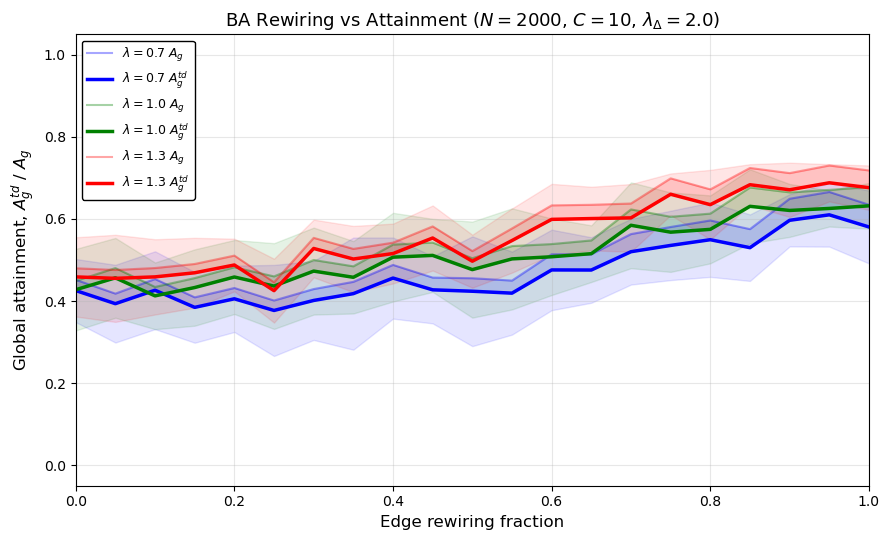

In [7]:
# ---- Attainment: per-lambda ----
fig, ax = plt.subplots(figsize=(9, 5.5))
for lam in LAMBDA_VALS:
    res = all_results[lam]
    color = LAMBDA_COLORS[lam]
    _plot_attainment(ax, REWIRE_FRACS, res, color,
                     label_prefix=rf'$\lambda={lam}$ ')

ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Edge rewiring fraction', fontsize=12)
ax.set_ylabel(r'Global attainment, $A_g^{td}$ / $A_g$', fontsize=12)
ax.set_title(
    rf'BA Rewiring vs Attainment ($N={N}$, $C={C}$, $\lambda_\Delta={LAMBDA_DELTA}$)',
    fontsize=13,
)
ax.legend(loc='best', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out_path = '../figures/hubbyness_attainment_per_lambda.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

Saved: ../figures/hubbyness_attainment_averaged.png


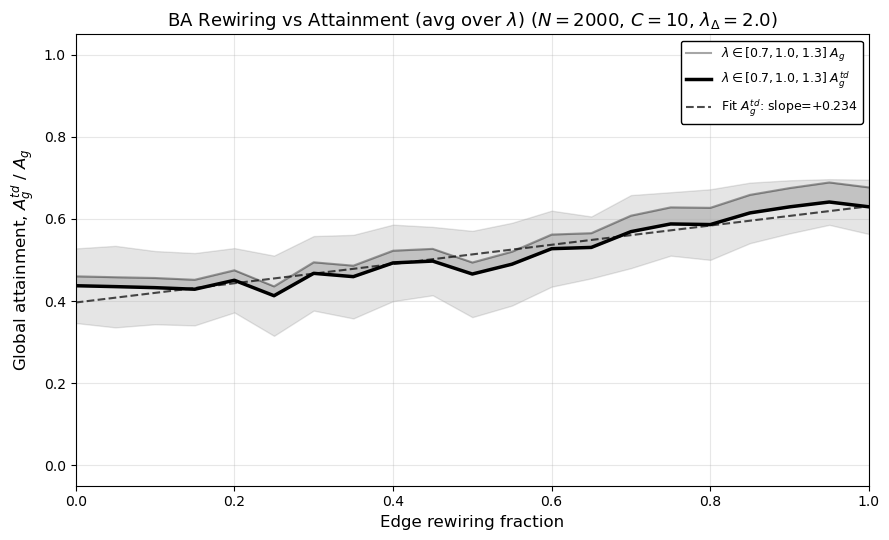

In [8]:
# ---- Attainment: averaged across lambda ----
fig, ax = plt.subplots(figsize=(9, 5.5))

# Compute average across lambda values
avg_res = {
    'Ag_mean': np.mean([all_results[lam]['Ag_mean'] for lam in LAMBDA_VALS], axis=0),
    'Ag_std': np.mean([all_results[lam]['Ag_std'] for lam in LAMBDA_VALS], axis=0),
    'Ag_td_mean': np.mean([all_results[lam]['Ag_td_mean'] for lam in LAMBDA_VALS], axis=0),
    'Ag_td_std': np.mean([all_results[lam]['Ag_td_std'] for lam in LAMBDA_VALS], axis=0),
}

_plot_attainment(ax, REWIRE_FRACS, avg_res, AVG_COLOR,
                 label_prefix=rf'$\lambda \in {LAMBDA_VALS}$ ')

# Line of best fit for A_g^td
coeffs_td = np.polyfit(REWIRE_FRACS, avg_res['Ag_td_mean'], 1)
fit_td = np.poly1d(coeffs_td)
ax.plot(REWIRE_FRACS, fit_td(REWIRE_FRACS),
        color=AVG_COLOR, ls='--', lw=1.5, alpha=0.7,
        label=rf'Fit $A_g^{{td}}$: slope={coeffs_td[0]:+.3f}')

ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('Edge rewiring fraction', fontsize=12)
ax.set_ylabel(r'Global attainment, $A_g^{td}$ / $A_g$', fontsize=12)
ax.set_title(
    rf'BA Rewiring vs Attainment (avg over $\lambda$) ($N={N}$, $C={C}$, $\lambda_\Delta={LAMBDA_DELTA}$)',
    fontsize=13,
)
ax.legend(loc='best', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out_path = '../figures/hubbyness_attainment_averaged.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

Saved: ../figures/hubbyness_deadweight_per_lambda.png


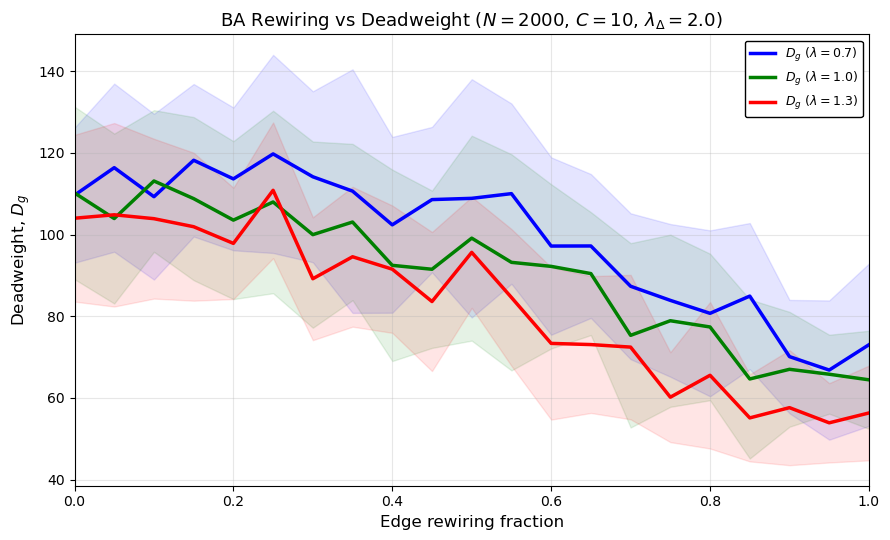

In [9]:
# ---- Deadweight: per-lambda ----
fig, ax = plt.subplots(figsize=(9, 5.5))
for lam in LAMBDA_VALS:
    res = all_results[lam]
    color = LAMBDA_COLORS[lam]
    _plot_metric(
        ax, REWIRE_FRACS, res['Dg_mean'], res['Dg_std'], color,
        label=rf'$D_g$ ($\lambda={lam}$)',
    )

ax.set_xlim(0, 1)
ax.set_xlabel('Edge rewiring fraction', fontsize=12)
ax.set_ylabel(r'Deadweight, $D_g$', fontsize=12)
ax.set_title(
    rf'BA Rewiring vs Deadweight ($N={N}$, $C={C}$, $\lambda_\Delta={LAMBDA_DELTA}$)',
    fontsize=13,
)
ax.legend(loc='best', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out_path = '../figures/hubbyness_deadweight_per_lambda.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

Saved: ../figures/hubbyness_deadweight_averaged.png


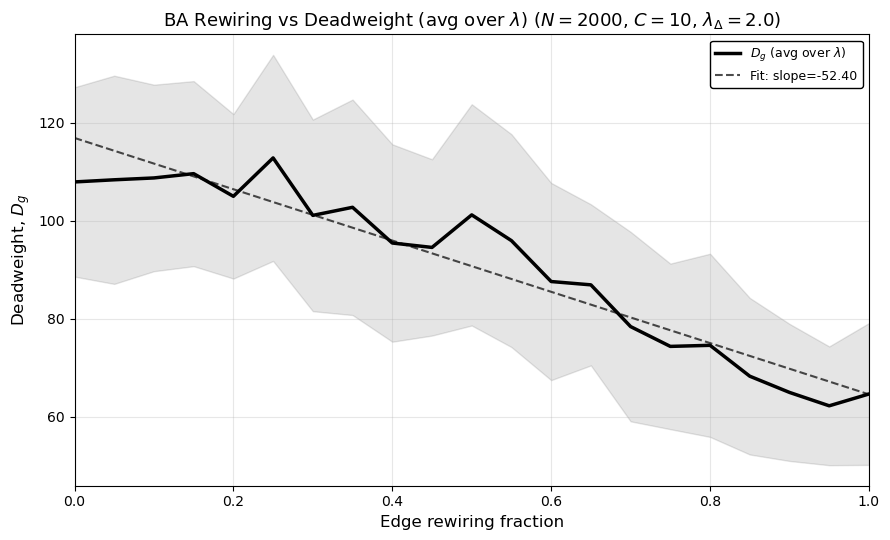

In [10]:
# ---- Deadweight: averaged across lambda ----
fig, ax = plt.subplots(figsize=(9, 5.5))

avg_Dg_mean = np.mean([all_results[lam]['Dg_mean'] for lam in LAMBDA_VALS], axis=0)
avg_Dg_std = np.mean([all_results[lam]['Dg_std'] for lam in LAMBDA_VALS], axis=0)

_plot_metric(
    ax, REWIRE_FRACS, avg_Dg_mean, avg_Dg_std, AVG_COLOR,
    label=rf'$D_g$ (avg over $\lambda$)',
)

# Line of best fit
coeffs_D = np.polyfit(REWIRE_FRACS, avg_Dg_mean, 1)
fit_D = np.poly1d(coeffs_D)
ax.plot(REWIRE_FRACS, fit_D(REWIRE_FRACS),
        color=AVG_COLOR, ls='--', lw=1.5, alpha=0.7,
        label=rf'Fit: slope={coeffs_D[0]:+.2f}')

ax.set_xlim(0, 1)
ax.set_xlabel('Edge rewiring fraction', fontsize=12)
ax.set_ylabel(r'Deadweight, $D_g$', fontsize=12)
ax.set_title(
    rf'BA Rewiring vs Deadweight (avg over $\lambda$) ($N={N}$, $C={C}$, $\lambda_\Delta={LAMBDA_DELTA}$)',
    fontsize=13,
)
ax.legend(loc='best', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out_path = '../figures/hubbyness_deadweight_averaged.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

Saved: ../figures/hubbyness_penetration_per_lambda.png


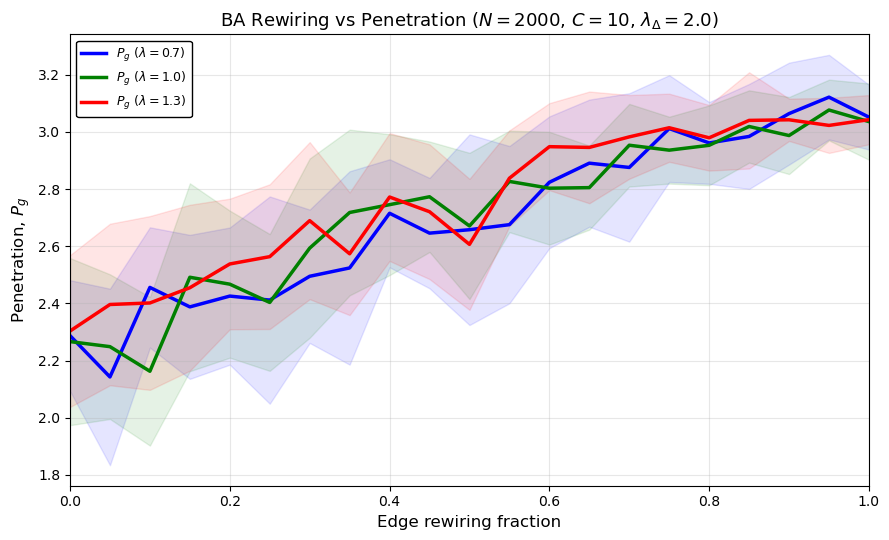

In [11]:
# ---- Penetration: per-lambda ----
fig, ax = plt.subplots(figsize=(9, 5.5))
for lam in LAMBDA_VALS:
    res = all_results[lam]
    color = LAMBDA_COLORS[lam]
    _plot_metric(
        ax, REWIRE_FRACS, res['Pg_mean'], res['Pg_std'], color,
        label=rf'$P_g$ ($\lambda={lam}$)',
    )

ax.set_xlim(0, 1)
ax.set_xlabel('Edge rewiring fraction', fontsize=12)
ax.set_ylabel(r'Penetration, $P_g$', fontsize=12)
ax.set_title(
    rf'BA Rewiring vs Penetration ($N={N}$, $C={C}$, $\lambda_\Delta={LAMBDA_DELTA}$)',
    fontsize=13,
)
ax.legend(loc='best', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out_path = '../figures/hubbyness_penetration_per_lambda.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

Saved: ../figures/hubbyness_penetration_averaged.png


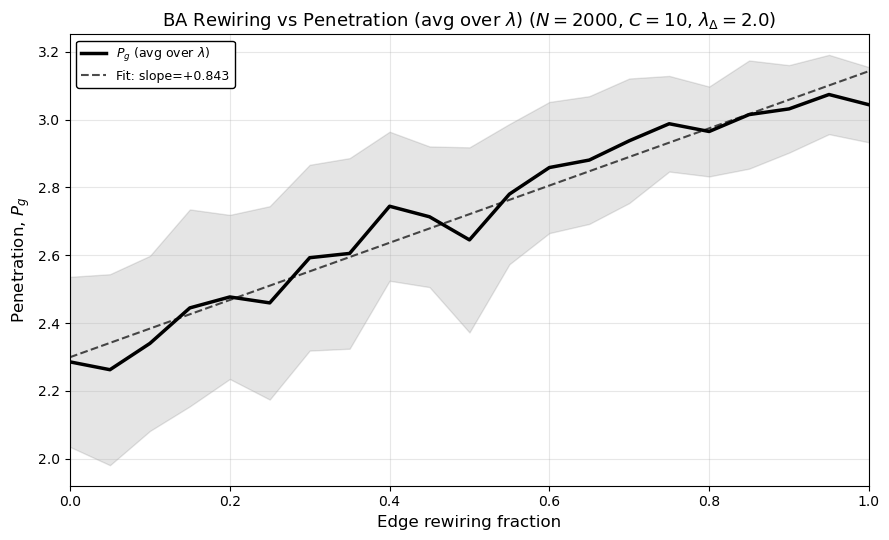

In [12]:
# ---- Penetration: averaged across lambda ----
fig, ax = plt.subplots(figsize=(9, 5.5))

avg_Pg_mean = np.mean([all_results[lam]['Pg_mean'] for lam in LAMBDA_VALS], axis=0)
avg_Pg_std = np.mean([all_results[lam]['Pg_std'] for lam in LAMBDA_VALS], axis=0)

_plot_metric(
    ax, REWIRE_FRACS, avg_Pg_mean, avg_Pg_std, AVG_COLOR,
    label=rf'$P_g$ (avg over $\lambda$)',
)

# Line of best fit
coeffs_P = np.polyfit(REWIRE_FRACS, avg_Pg_mean, 1)
fit_P = np.poly1d(coeffs_P)
ax.plot(REWIRE_FRACS, fit_P(REWIRE_FRACS),
        color=AVG_COLOR, ls='--', lw=1.5, alpha=0.7,
        label=rf'Fit: slope={coeffs_P[0]:+.3f}')

ax.set_xlim(0, 1)
ax.set_xlabel('Edge rewiring fraction', fontsize=12)
ax.set_ylabel(r'Penetration, $P_g$', fontsize=12)
ax.set_title(
    rf'BA Rewiring vs Penetration (avg over $\lambda$) ($N={N}$, $C={C}$, $\lambda_\Delta={LAMBDA_DELTA}$)',
    fontsize=13,
)
ax.legend(loc='best', framealpha=1, edgecolor='black', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
out_path = '../figures/hubbyness_penetration_averaged.png'
plt.savefig(out_path, dpi=300, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()